# Actividad 10 — Reexploracion Post-ETL

**Proyecto:** Prediccion de Produccion de Limon en el Peru  
**Pipeline:** Fase 1 — Ingenieria de Datos  

---

## Objetivo
Validar que el dataset maestro generado por el ETL es correcto, completo y listo para el modelo LSTM-Attention. Se explora con los **valores originales** (sin escalar) para facilitar la interpretacion.

## Regla de esta actividad
> No se modifica ningun dato. Si algo no coincide con lo esperado, se debe volver a la actividad correspondiente y corregir.


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
OUTPUT = CONFIG['output']

PG_USER = 'postgres'
PG_PASS = 'postgres'
PG_HOST = 'localhost'
PG_PORT = '5432'
PG_DB   = 'limon_analytics_db'

os.makedirs(OUTPUT['reexploracion'], exist_ok=True)
print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


---
# 1. Carga y Validacion del Dataset Maestro


In [2]:
# Cargar dataset con valores originales (sin escalar)
df = pd.read_csv(OUTPUT['etl'] + 'master_dataset_raw_values.csv')
df_scaled = pd.read_csv(OUTPUT['etl'] + 'master_dataset_fase1.csv')

print('=== DATASET MAESTRO FINAL ===')
print(f'Shape (valores originales): {df.shape}')
print(f'Shape (escalado):           {df_scaled.shape}')
print()
print(f'Columnas: {df.columns.tolist()}')
print()
print(f'Rango temporal: {df["fecha_evento"].min()} -> {df["fecha_evento"].max()}')
print(f'Meses: {df["fecha_evento"].nunique()}')
print(f'Departamentos: {df["departamento"].nunique()}')
print(f'Provincias: {df["provincia"].nunique()}')
print()

# Validacion de calidad
nulos = df.isnull().sum().sum()
dupes = df.duplicated(subset=['fecha_evento','departamento','provincia']).sum()
print(f'Nulos totales: {nulos}')
print(f'Duplicados en llave maestra: {dupes}')
print()

if nulos == 0 and dupes == 0:
    print('OK: Dataset maestro validado. Listo para el modelo LSTM-Attention.')
else:
    print('ADVERTENCIA: Hay problemas de calidad. Revisar el pipeline.')

print()
print('Estadisticas descriptivas:')
cols_num = [c for c in df.columns if df[c].dtype in ['float64','int64']
            and c not in ['fecha_evento','departamento','provincia']]
display(df[cols_num].describe().round(3))


=== DATASET MAESTRO FINAL ===
Shape (valores originales): (5880, 17)
Shape (escalado):           (5880, 17)

Columnas: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M', 'n_noticias']

Rango temporal: 2021-01 -> 2025-08
Meses: 56
Departamentos: 23
Provincias: 105

Nulos totales: 0
Duplicados en llave maestra: 0

OK: Dataset maestro validado. Listo para el modelo LSTM-Attention.

Estadisticas descriptivas:


,produccion_t,cosecha_ha,precio_chacra_kg,num_emergencias,total_afectados,ALLSKY_SFC_SW_DWN,PRECTOTCORR,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M,n_noticias
count,5880.000,5880.0,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000
mean,17.082,0.0,1.498,1.055,30.688,17.787,55.441,11.579,72.094,18.496,27.082,11.845,1.617,8.929
std,28.504,0.0,0.588,3.509,317.719,2.959,74.064,3.511,11.540,6.400,5.842,7.498,1.139,5.487
min,0.000,0.0,0.250,0.000,0.000,9.220,0.000,1.840,22.690,3.420,13.390,-5.930,0.010,0.000
25%,0.000,0.0,1.000,0.000,0.000,15.680,7.485,9.170,66.060,13.408,22.660,5.848,0.250,5.000
50%,5.540,0.0,1.400,0.000,0.000,17.490,29.760,11.525,72.250,18.765,27.130,12.595,1.700,8.000
75%,22.000,0.0,2.000,0.000,0.000,19.250,70.370,13.712,79.592,23.952,30.952,17.900,2.310,13.000
max,228.800,0.0,2.650,52.000,12379.000,30.860,667.430,20.370,93.920,33.660,42.400,25.510,5.360,26.000


### Interpretacion

**Que muestra:** El estado final del dataset maestro. 0 nulos y 0 duplicados confirman que el pipeline completo fue exitoso.

**Comparacion con el inicio:** El dataset paso de 4 fuentes separadas con problemas de calidad a un unico dataset integrado, limpio y escalado.

**Implicacion para el modelo:** Este dataset es la entrada directa al LSTM-Attention. La calidad del modelo depende directamente de la calidad de este dataset.


---
# 2. Grafico 1 — Serie Temporal de Produccion Final


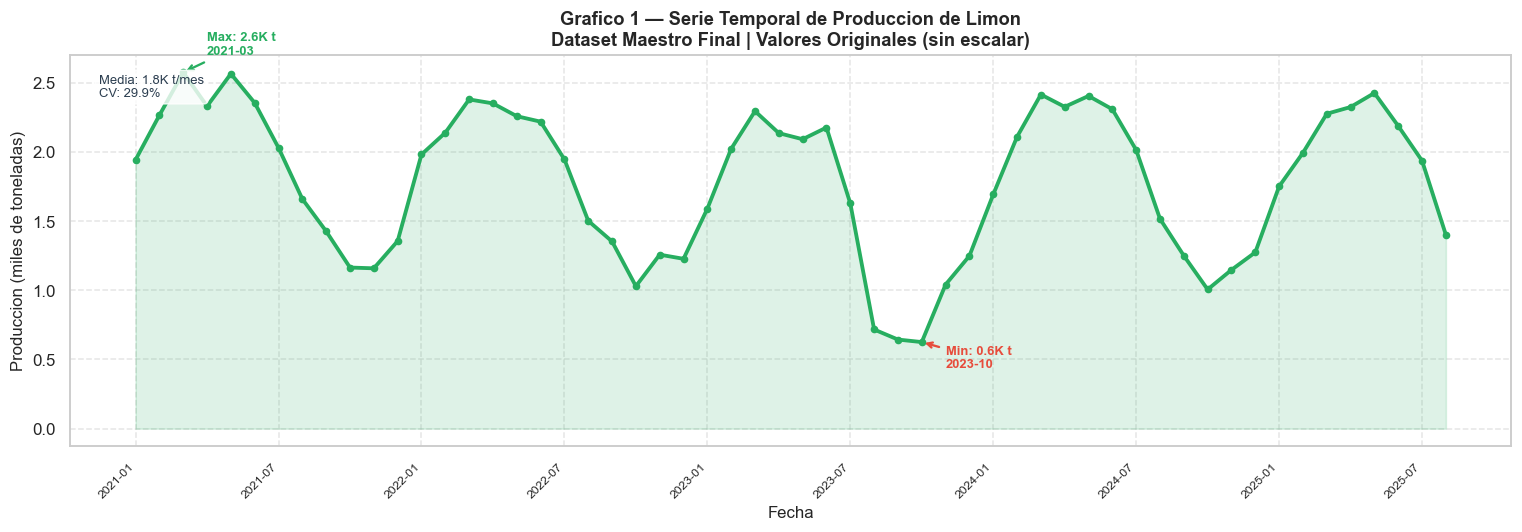

Guardado: pipeline/output/10_reexploracion/act10_g1_serie_produccion.png
Produccion media mensual: 1.8K t
Coeficiente de variacion: 29.9%


In [3]:
col_prod = 'produccion_t' if 'produccion_t' in df.columns else None

if col_prod:
    serie = df.groupby('fecha_evento')[col_prod].sum().reset_index()
    serie = serie.sort_values('fecha_evento')

    idx_max = serie[col_prod].idxmax()
    idx_min = serie[col_prod].idxmin()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(range(len(serie)), serie[col_prod]/1e3,
            color='#27ae60', linewidth=2.5, marker='o', markersize=4, zorder=3)
    ax.fill_between(range(len(serie)), serie[col_prod]/1e3,
                    alpha=0.15, color='#27ae60')

    # Anotaciones max y min
    ax.annotate(
        f'Max: {serie.loc[idx_max,col_prod]/1e3:.1f}K t\n{serie.loc[idx_max,"fecha_evento"]}',
        xy=(idx_max, serie.loc[idx_max,col_prod]/1e3),
        xytext=(idx_max+1, serie.loc[idx_max,col_prod]/1e3 * 1.05),
        fontsize=8.5, color='#27ae60', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5)
    )
    ax.annotate(
        f'Min: {serie.loc[idx_min,col_prod]/1e3:.1f}K t\n{serie.loc[idx_min,"fecha_evento"]}',
        xy=(idx_min, serie.loc[idx_min,col_prod]/1e3),
        xytext=(idx_min+1, serie.loc[idx_min,col_prod]/1e3 * 0.7),
        fontsize=8.5, color='#e74c3c', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5)
    )

    ax.set_xticks(range(0, len(serie), 6))
    ax.set_xticklabels(serie['fecha_evento'].iloc[::6], rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Produccion (miles de toneladas)', fontsize=11)
    ax.set_title('Grafico 1 — Serie Temporal de Produccion de Limon\n'
                 'Dataset Maestro Final | Valores Originales (sin escalar)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

    # Estadisticas en el grafico
    stats_txt = (f'Media: {serie[col_prod].mean()/1e3:.1f}K t/mes\n'
                 f'CV: {serie[col_prod].std()/serie[col_prod].mean()*100:.1f}%')
    ax.text(0.02, 0.95, stats_txt, transform=ax.transAxes,
            fontsize=8.5, va='top', color='#2c3e50',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    g1 = OUTPUT['reexploracion'] + 'act10_g1_serie_produccion.png'
    plt.savefig(g1, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g1)
    print(f'Produccion media mensual: {serie[col_prod].mean()/1e3:.1f}K t')
    print(f'Coeficiente de variacion: {serie[col_prod].std()/serie[col_prod].mean()*100:.1f}%')


### Interpretacion

**Que muestra:** La serie temporal de produccion de limon del dataset maestro final. El patron estacional debe ser visible y coherente con los datos originales de MIDAGRI.

**Validacion:** Si la serie tiene saltos bruscos o valores negativos, indica un problema en el ETL. La serie debe ser identica a la del EDA (Actividad 3).

**Implicacion para el modelo:** Esta es la variable objetivo del LSTM-Attention. El modelo aprendera a predecir esta serie usando las variables exogenas (clima, emergencias, noticias) como entrada.


---
# 3. Grafico 2 — Distribuciones Finales de Variables Clave


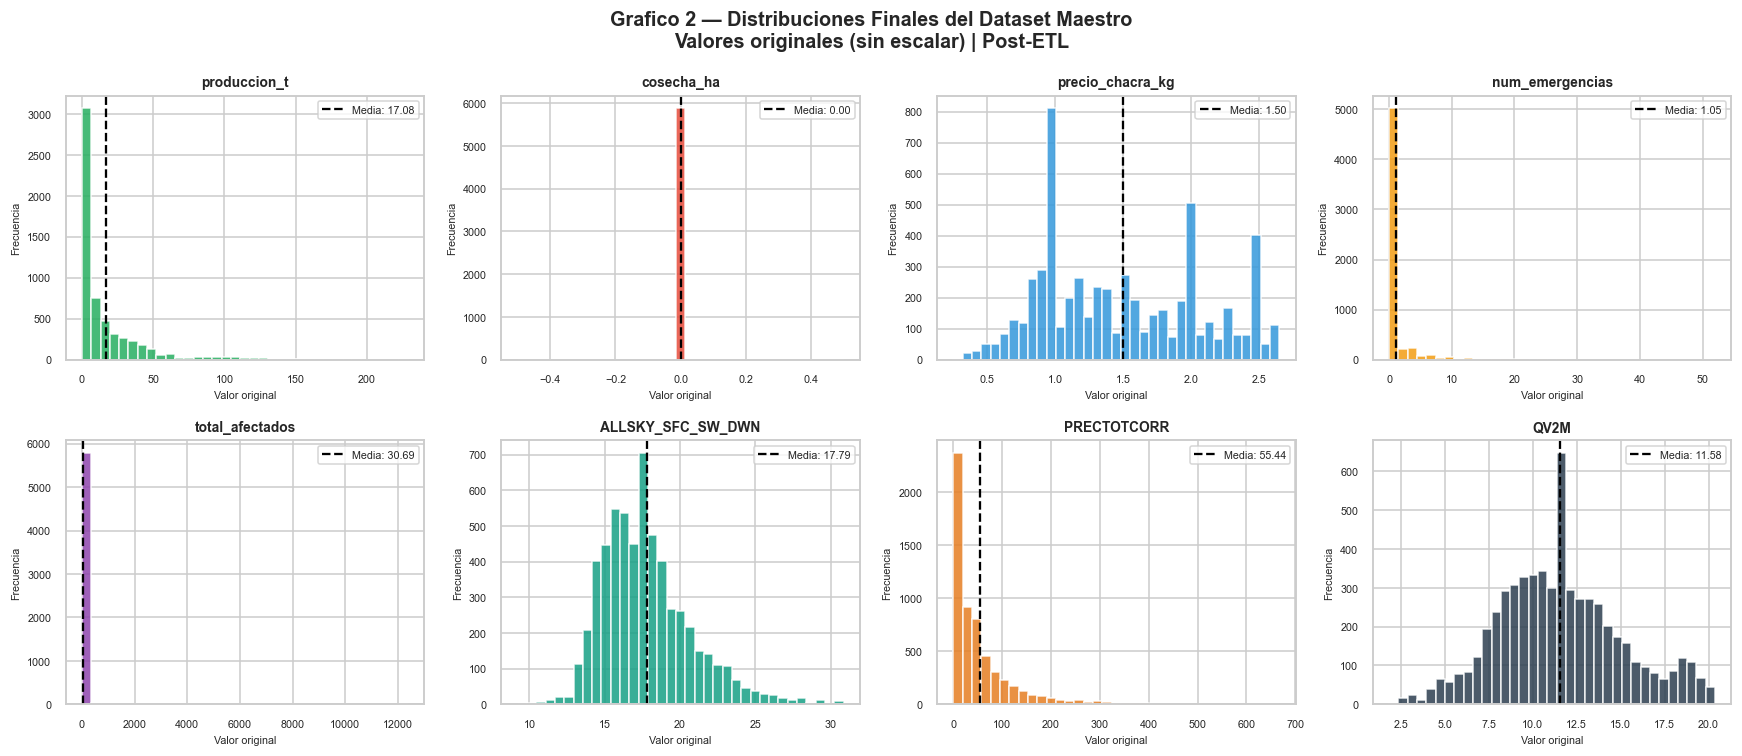

Guardado: pipeline/output/10_reexploracion/act10_g2_distribuciones.png


In [4]:
vars_plot = [c for c in cols_num if c in df.columns][:8]
n_vars = len(vars_plot)
ncols = 4
nrows = (n_vars + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*3.5))
axes = axes.flatten()
colores = ['#27ae60','#e74c3c','#3498db','#f39c12',
           '#8e44ad','#16a085','#e67e22','#2c3e50']

for i, (var, color) in enumerate(zip(vars_plot, colores)):
    data = df[var].dropna()
    axes[i].hist(data, bins=35, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Media: {data.mean():.2f}')
    axes[i].set_title(var, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Valor original', fontsize=7)
    axes[i].set_ylabel('Frecuencia', fontsize=7)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Grafico 2 — Distribuciones Finales del Dataset Maestro\n'
             'Valores originales (sin escalar) | Post-ETL',
             fontsize=13, fontweight='bold')
plt.tight_layout()
g2 = OUTPUT['reexploracion'] + 'act10_g2_distribuciones.png'
plt.savefig(g2, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g2)


### Interpretacion

**Que muestra:** Las distribuciones de las variables clave del dataset maestro con valores originales. Deben ser similares a las del EDA (Actividad 3).

**Validacion:** Si alguna distribucion tiene valores fuera de rango fisico (temperatura negativa extrema, produccion negativa), indica un problema en el pipeline.

**Implicacion para el modelo:** Las distribuciones razonables confirman que el StandardScaler de la Actividad 9 funcionara correctamente y que el LSTM-Attention recibira datos de calidad.


---
# 4. Grafico 3 — Cobertura Multimodal por Departamento


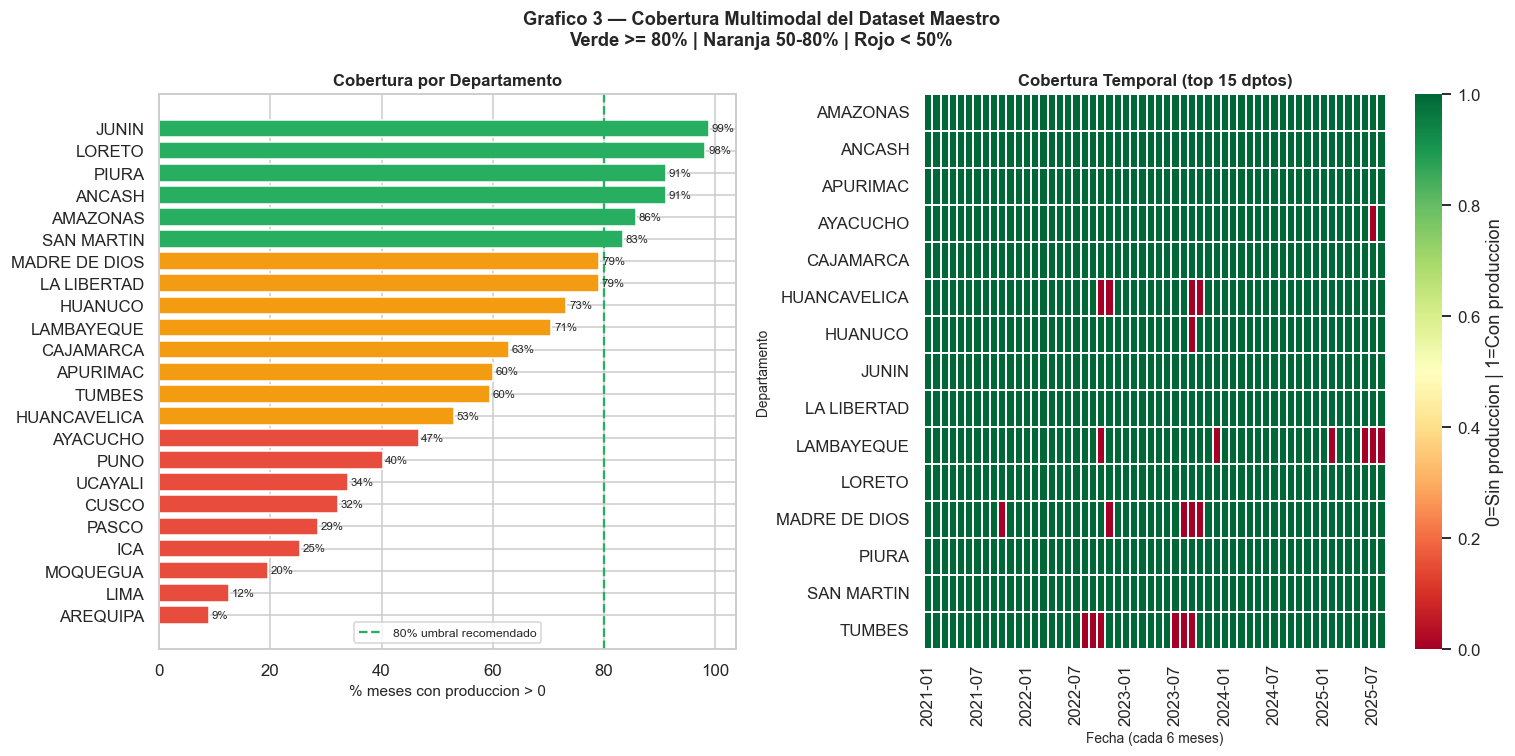

Guardado: pipeline/output/10_reexploracion/act10_g3_cobertura.png
Departamentos con >= 80% cobertura: 6
Departamentos con < 50% cobertura: 9


In [5]:
# Calcular cobertura: % de meses con produccion > 0 por departamento
if col_prod:
    cobertura = df.groupby('departamento').apply(
        lambda x: (x[col_prod] > 0).mean() * 100
    ).sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Barras de cobertura
    colors_cob = ['#27ae60' if v >= 80 else '#f39c12' if v >= 50 else '#e74c3c'
                  for v in cobertura.values]
    axes[0].barh(cobertura.index, cobertura.values, color=colors_cob, edgecolor='white')
    axes[0].axvline(80, color='#27ae60', linestyle='--', linewidth=1.5,
                    label='80% umbral recomendado')
    for i, val in enumerate(cobertura.values):
        axes[0].text(val+0.5, i, f'{val:.0f}%', va='center', fontsize=7.5)
    axes[0].set_xlabel('% meses con produccion > 0', fontsize=10)
    axes[0].set_title('Cobertura por Departamento', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=8)

    # Heatmap cobertura temporal
    top_dptos = cobertura.sort_values(ascending=False).head(15).index.tolist()
    df_top = df[df['departamento'].isin(top_dptos)]
    pivot = df_top.pivot_table(
        index='departamento', columns='fecha_evento',
        values=col_prod, aggfunc='sum', fill_value=0
    )
    pivot_bool = (pivot > 0).astype(int)

    sns.heatmap(pivot_bool, cmap='RdYlGn', ax=axes[1],
                xticklabels=6, linewidths=0.1,
                cbar_kws={'label': '0=Sin produccion | 1=Con produccion'})
    axes[1].set_title('Cobertura Temporal (top 15 dptos)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Fecha (cada 6 meses)', fontsize=9)
    axes[1].set_ylabel('Departamento', fontsize=9)

    plt.suptitle('Grafico 3 — Cobertura Multimodal del Dataset Maestro\n'
                 'Verde >= 80% | Naranja 50-80% | Rojo < 50%',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    g3 = OUTPUT['reexploracion'] + 'act10_g3_cobertura.png'
    plt.savefig(g3, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g3)
    print(f'Departamentos con >= 80% cobertura: {(cobertura >= 80).sum()}')
    print(f'Departamentos con < 50% cobertura: {(cobertura < 50).sum()}')


### Interpretacion

**Que muestra:** El porcentaje de meses con produccion registrada por departamento. Los departamentos con alta cobertura (verde) son los mas confiables para el modelo.

**Implicacion para el pipeline:** Los departamentos con baja cobertura (<50%) tienen muchos meses con produccion=0, lo que puede dificultar el aprendizaje del LSTM. Se evaluara en la Fase 2 si se filtran estos departamentos.

**Implicacion para el modelo:** La cobertura temporal determina la calidad de las series temporales disponibles para entrenamiento. Series con muchos ceros pueden generar predicciones sesgadas.


---
# 5. Grafico 4 — Correlaciones Finales del Dataset Maestro


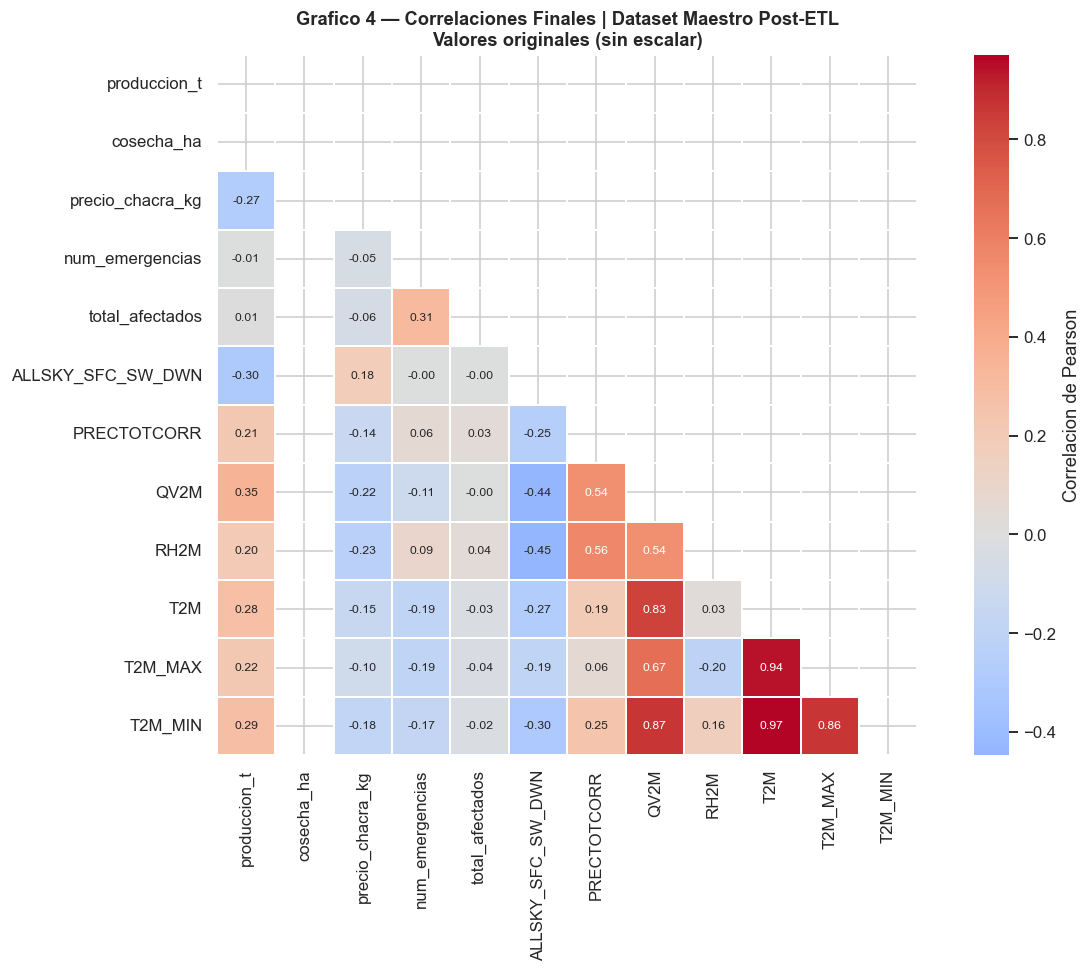

Guardado: pipeline/output/10_reexploracion/act10_g4_correlacion.png

Top 5 variables mas correlacionadas con produccion_t:
  QV2M                      r =   0.354  [MEDIA]
  ALLSKY_SFC_SW_DWN         r =  -0.299  [BAJA]
  T2M_MIN                   r =   0.288  [BAJA]
  T2M                       r =   0.277  [BAJA]
  precio_chacra_kg          r =  -0.273  [BAJA]


In [6]:
cols_corr = [c for c in cols_num if c in df.columns][:12]
corr_final = df[cols_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(corr_final, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, ax=ax,
            cbar_kws={'label': 'Correlacion de Pearson'},
            annot_kws={'size': 8}, linewidths=0.3)
ax.set_title('Grafico 4 — Correlaciones Finales | Dataset Maestro Post-ETL\n'
             'Valores originales (sin escalar)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g4 = OUTPUT['reexploracion'] + 'act10_g4_correlacion.png'
plt.savefig(g4, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g4)
print()
if col_prod in corr_final.columns:
    corr_prod = corr_final[col_prod].drop(col_prod).sort_values(key=abs, ascending=False)
    print('Top 5 variables mas correlacionadas con produccion_t:')
    for var, r in corr_prod.head(5).items():
        nivel = 'ALTA' if abs(r) > 0.5 else 'MEDIA' if abs(r) > 0.3 else 'BAJA'
        print(f'  {var:<25} r = {r:>7.3f}  [{nivel}]')


### Interpretacion

**Que muestra:** La correlacion entre todas las variables del dataset maestro con valores originales. Debe ser similar al heatmap del EDA (Actividad 3).

**Validacion:** Si las correlaciones cambiaron significativamente respecto al EDA, indica que el proceso de integracion o limpieza introdujo algun sesgo.

**Implicacion para el modelo:** Las variables con alta correlacion con `produccion_t` son las mas importantes para el LSTM-Attention. Este heatmap es la evidencia final que justifica la arquitectura multimodal.


---
# 6. Grafico 5 — Validacion desde PostgreSQL


PostgreSQL conectado OK
Consulta 1 — Top 10 departamentos por produccion (SQL):
  LORETO                         423.5
  JUNIN                          410.9
  SAN MARTIN                     375.2
  AMAZONAS                       111.7
  PIURA                          7.9
  CUSCO                          2.1
  HUANUCO                        -9.1
  PASCO                          -19.0
  LAMBAYEQUE                     -19.9
  MADRE DE DIOS                  -24.2

Consulta 3 — Temperatura media por año (SQL):
  2021: -0.07 C
  2022: -0.08 C
  2023: 0.08 C
  2024: 0.12 C
  2025: -0.07 C


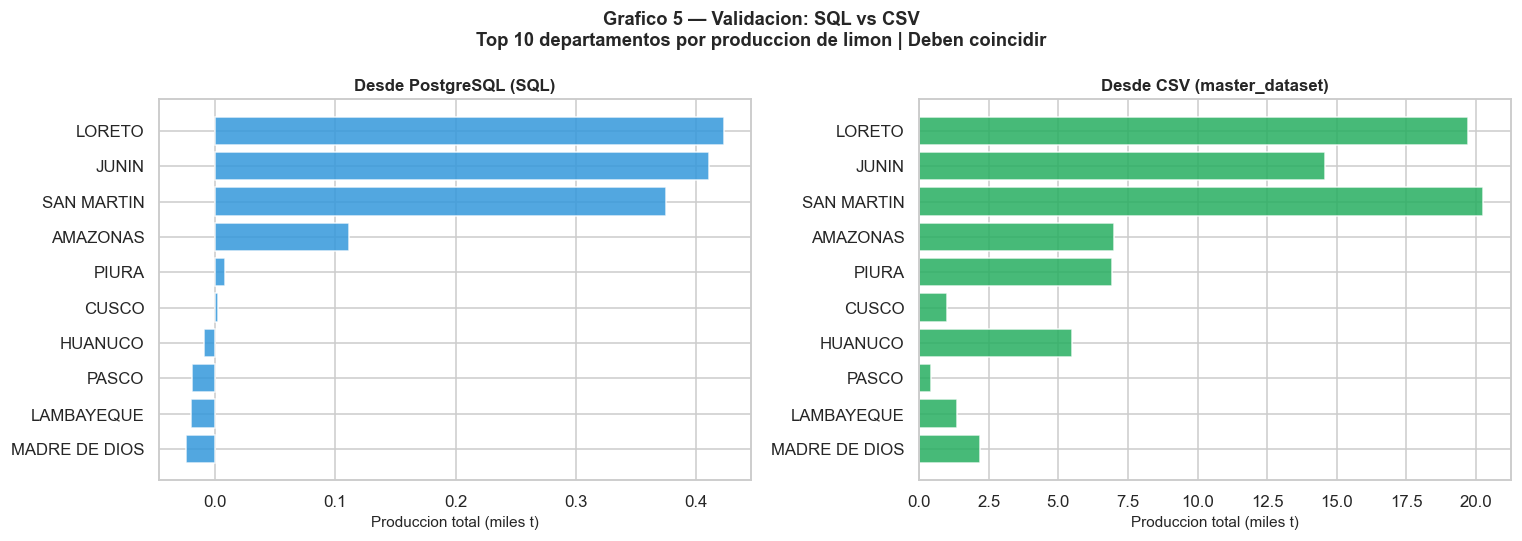

Guardado: pipeline/output/10_reexploracion/act10_g5_sql_vs_csv.png


In [7]:
try:
    import psycopg2
    conn = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB, connect_timeout=5
    )
    cursor = conn.cursor()
    PG_OK = True
    print('PostgreSQL conectado OK')
except Exception as e:
    PG_OK = False
    print(f'PostgreSQL no disponible: {e}')

if PG_OK:
    # Consulta 1: produccion total por departamento
    cursor.execute("""
        SELECT u.departamento,
               SUM(f.produccion_t) as prod_total
        FROM fact_produccion_limon f
        JOIN dim_ubicacion u ON f.id_ubicacion = u.id_ubicacion
        GROUP BY u.departamento
        ORDER BY prod_total DESC
        LIMIT 10;
    """)
    top_dptos_sql = cursor.fetchall()

    # Consulta 2: promedio emergencias por mes
    cursor.execute("""
        SELECT t.fecha_evento,
               AVG(e.num_emergencias) as avg_emer
        FROM fact_produccion_limon f
        JOIN dim_tiempo t ON f.id_tiempo = t.id_tiempo
        JOIN dim_emergencia e ON f.id_emergencia = e.id_emergencia
        GROUP BY t.fecha_evento
        ORDER BY t.fecha_evento
        LIMIT 12;
    """)
    emer_mensual_sql = cursor.fetchall()

    # Consulta 3: temperatura media por año
    cursor.execute("""
        SELECT t.anho,
               AVG(c.t2m) as temp_media
        FROM fact_produccion_limon f
        JOIN dim_tiempo t ON f.id_tiempo = t.id_tiempo
        JOIN dim_clima c ON f.id_clima = c.id_clima
        GROUP BY t.anho
        ORDER BY t.anho;
    """)
    temp_anual_sql = cursor.fetchall()

    cursor.close()
    conn.close()

    print('Consulta 1 — Top 10 departamentos por produccion (SQL):')
    for dpto, prod in top_dptos_sql:
        print(f'  {dpto:<30} {prod:.1f}')

    print()
    print('Consulta 3 — Temperatura media por año (SQL):')
    for anho, temp in temp_anual_sql:
        print(f'  {anho}: {temp:.2f} C')

    # Grafico: top departamentos SQL vs CSV
    dptos_sql = [r[0] for r in top_dptos_sql]
    prods_sql = [r[1] for r in top_dptos_sql]

    # Calcular lo mismo desde el CSV para comparar
    if col_prod:
        prods_csv = [df[df['departamento']==d][col_prod].sum() for d in dptos_sql]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Desde SQL
        axes[0].barh(dptos_sql[::-1], [p/1e3 for p in prods_sql[::-1]],
                     color='#3498db', edgecolor='white', alpha=0.85)
        axes[0].set_xlabel('Produccion total (miles t)', fontsize=10)
        axes[0].set_title('Desde PostgreSQL (SQL)', fontsize=11, fontweight='bold')

        # Desde CSV
        axes[1].barh(dptos_sql[::-1], [p/1e3 for p in prods_csv[::-1]],
                     color='#27ae60', edgecolor='white', alpha=0.85)
        axes[1].set_xlabel('Produccion total (miles t)', fontsize=10)
        axes[1].set_title('Desde CSV (master_dataset)', fontsize=11, fontweight='bold')

        plt.suptitle('Grafico 5 — Validacion: SQL vs CSV\n'
                     'Top 10 departamentos por produccion de limon | Deben coincidir',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        g5 = OUTPUT['reexploracion'] + 'act10_g5_sql_vs_csv.png'
        plt.savefig(g5, dpi=120, bbox_inches='tight'); plt.show()
        print('Guardado:', g5)
else:
    print('PostgreSQL no disponible. Validacion SQL omitida.')


### Interpretacion

**Que muestra:** La comparacion entre los resultados de consultas SQL en PostgreSQL y los calculos directos sobre el CSV. Deben coincidir exactamente.

**Validacion critica:** Si los valores difieren, indica que la carga en PostgreSQL (Actividad 9) tuvo algun problema. Se debe re-ejecutar la Actividad 9.

**Implicacion para el pipeline:** La consistencia entre SQL y CSV confirma que el Star Schema es una representacion fiel del dataset maestro, lo que permite usar ambas fuentes indistintamente para el modelo.


---
# 7. Grafico 6 — Resumen Visual del Pipeline Completo


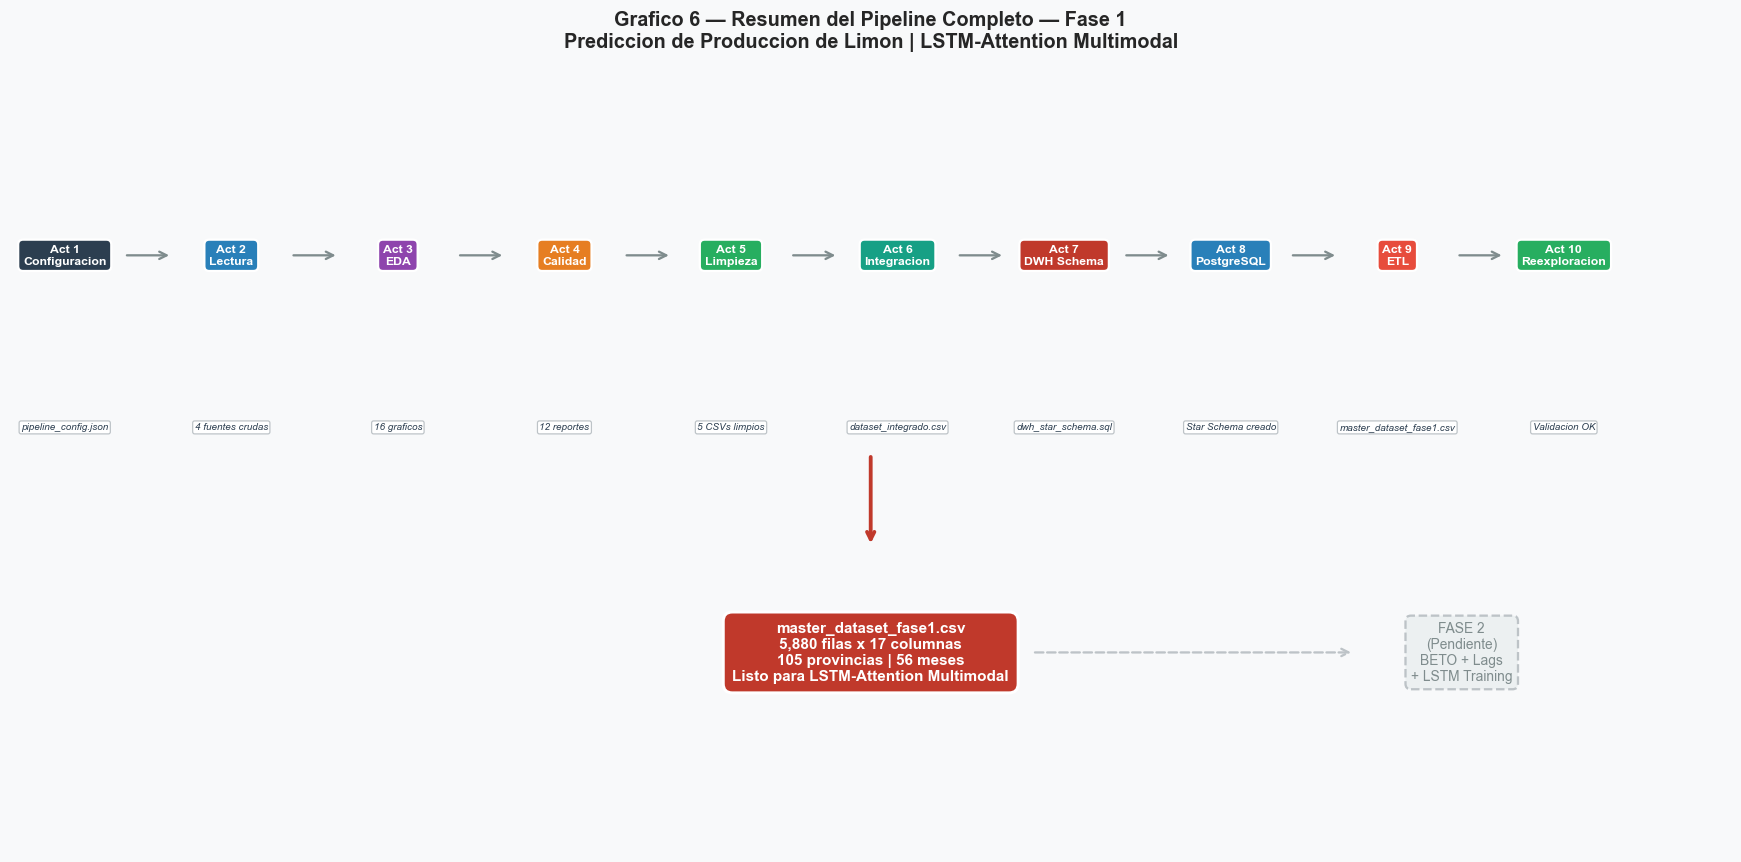

Guardado: pipeline/output/10_reexploracion/act10_g6_resumen_pipeline.png


In [8]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

actividades = [
    ('Act 1\nConfiguracion', '#2c3e50', 'pipeline_config.json'),
    ('Act 2\nLectura', '#2980b9', '4 fuentes crudas'),
    ('Act 3\nEDA', '#8e44ad', '16 graficos'),
    ('Act 4\nCalidad', '#e67e22', '12 reportes'),
    ('Act 5\nLimpieza', '#27ae60', '5 CSVs limpios'),
    ('Act 6\nIntegracion', '#16a085', 'dataset_integrado.csv'),
    ('Act 7\nDWH Schema', '#c0392b', 'dwh_star_schema.sql'),
    ('Act 8\nPostgreSQL', '#2980b9', 'Star Schema creado'),
    ('Act 9\nETL', '#e74c3c', 'master_dataset_fase1.csv'),
    ('Act 10\nReexploracion', '#27ae60', 'Validacion OK'),
]

x_positions = [i * 1.55 + 0.5 for i in range(len(actividades))]

for i, ((texto, color, salida), x) in enumerate(zip(actividades, x_positions)):
    # Caja de actividad
    ax.text(x, 5.5, texto, ha='center', va='center', fontsize=8,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color,
                      edgecolor='white', linewidth=1.5))
    # Salida
    ax.text(x, 4.2, salida, ha='center', va='center', fontsize=6.5,
            color='#2c3e50', style='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='#bdc3c7', linewidth=0.8))
    # Flecha
    if i < len(actividades) - 1:
        ax.annotate('', xy=(x_positions[i+1]-0.55, 5.5), xytext=(x+0.55, 5.5),
                    arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))

# Dataset final destacado
ax.text(8, 2.5,
    'master_dataset_fase1.csv\n'
    f'{df_scaled.shape[0]:,} filas x {df_scaled.shape[1]} columnas\n'
    f'{df["provincia"].nunique()} provincias | {df["fecha_evento"].nunique()} meses\n'
    'Listo para LSTM-Attention Multimodal',
    ha='center', va='center', fontsize=10, fontweight='bold', color='white',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#c0392b',
              edgecolor='white', linewidth=2)
)

# Flecha hacia el dataset final
ax.annotate('', xy=(8, 3.3), xytext=(8, 4.0),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2.5))

# Fase 2
ax.text(13.5, 2.5,
    'FASE 2\n(Pendiente)\nBETO + Lags\n+ LSTM Training',
    ha='center', va='center', fontsize=9, color='#7f8c8d',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1',
              edgecolor='#bdc3c7', linewidth=1.5, linestyle='--')
)
ax.annotate('', xy=(12.5, 2.5), xytext=(9.5, 2.5),
            arrowprops=dict(arrowstyle='->', color='#bdc3c7', lw=1.5,
                            linestyle='dashed'))

ax.set_xlim(0, 16)
ax.set_ylim(1, 7)
ax.set_title('Grafico 6 — Resumen del Pipeline Completo — Fase 1\n'
             'Prediccion de Produccion de Limon | LSTM-Attention Multimodal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
g6 = OUTPUT['reexploracion'] + 'act10_g6_resumen_pipeline.png'
plt.savefig(g6, dpi=130, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('Guardado:', g6)


### Interpretacion

**Que muestra:** El flujo completo del pipeline de la Fase 1, desde la configuracion hasta el dataset maestro final. Cada actividad muestra su salida principal.

**Implicacion para la tesis:** Este diagrama es el resumen visual del trabajo de ingenieria de datos realizado. Puede usarse directamente en la presentacion para explicar el pipeline a los evaluadores.

**Proximos pasos (Fase 2):** El dataset maestro sera la entrada del modelo LSTM-Attention. La Fase 2 incluira: analisis de sentimiento con BETO, generacion de lags temporales, codificacion ciclica (month_sin/cos) y entrenamiento del modelo.


---
# 8. Reporte Final del Pipeline


In [9]:
print('=' * 70)
print('  ACTIVIDAD 10 COMPLETADA — REEXPLORACION POST-ETL')
print('  PIPELINE FASE 1 COMPLETADO')
print('=' * 70)
print()
print('DATASET MAESTRO FINAL:')
print(f'  Archivo: {OUTPUT["etl"]}master_dataset_fase1.csv')
print(f'  Shape: {df_scaled.shape}')
print(f'  Rango: {df["fecha_evento"].min()} -> {df["fecha_evento"].max()}')
print(f'  Provincias: {df["provincia"].nunique()}')
print(f'  Departamentos: {df["departamento"].nunique()}')
print(f'  Nulos: 0 | Duplicados: 0')
print()
print('VARIABLES DEL DATASET:')
for i, col in enumerate(df_scaled.columns):
    print(f'  [{i:02d}] {col}')
print()
print('ARCHIVOS GENERADOS EN EL PIPELINE:')
archivos_pipeline = [
    ('pipeline/config/pipeline_config.json', 'Configuracion centralizada'),
    (OUTPUT['limpieza'] + 'midagri_limon_clean.csv', 'MIDAGRI limpio'),
    (OUTPUT['limpieza'] + 'indeci_eventos_clean.csv', 'INDECI limpio'),
    (OUTPUT['limpieza'] + 'nasa_long_clean.csv', 'NASA limpio'),
    (OUTPUT['limpieza'] + 'agraria_noticias_clean.csv', 'Agraria limpio'),
    (OUTPUT['integracion'] + 'dataset_integrado.csv', 'Dataset integrado'),
    (OUTPUT['dwh'] + 'dwh_star_schema.sql', 'DDL PostgreSQL'),
    (OUTPUT['etl'] + 'master_dataset_fase1.csv', 'Dataset maestro (escalado)'),
    (OUTPUT['etl'] + 'master_dataset_raw_values.csv', 'Dataset maestro (original)'),
    ('models/scalers/scaler_fase1.pkl', 'StandardScaler'),
]
for path, desc in archivos_pipeline:
    if os.path.exists(path):
        kb = os.path.getsize(path)//1024
        print(f'  OK  {desc:<35} {kb} KB')
    else:
        print(f'  FALTA {desc}')
print()
print('GRAFICOS GENERADOS:')
graficos = sorted(glob.glob(OUTPUT['reexploracion'] + 'act10_*.png'))
for g in graficos:
    print(f'  {os.path.basename(g)}')
print()
print('PENDIENTE PARA FASE 2:')
print('  - Analisis de sentimiento con BETO (noticias Agraria.pe)')
print('  - Generacion de lags temporales (t-1, t-3, t-6)')
print('  - Codificacion ciclica (month_sin, month_cos)')
print('  - Entrenamiento del modelo LSTM-Attention')
print('  - Evaluacion y explicabilidad (SHAP)')
print('  - Dashboard de prediccion (Streamlit)')


  ACTIVIDAD 10 COMPLETADA — REEXPLORACION POST-ETL
  PIPELINE FASE 1 COMPLETADO

DATASET MAESTRO FINAL:
  Archivo: pipeline/output/09_etl/master_dataset_fase1.csv
  Shape: (5880, 17)
  Rango: 2021-01 -> 2025-08
  Provincias: 105
  Departamentos: 23
  Nulos: 0 | Duplicados: 0

VARIABLES DEL DATASET:
  [00] fecha_evento
  [01] departamento
  [02] provincia
  [03] produccion_t
  [04] cosecha_ha
  [05] precio_chacra_kg
  [06] num_emergencias
  [07] total_afectados
  [08] ALLSKY_SFC_SW_DWN
  [09] PRECTOTCORR
  [10] QV2M
  [11] RH2M
  [12] T2M
  [13] T2M_MAX
  [14] T2M_MIN
  [15] WS2M
  [16] n_noticias

ARCHIVOS GENERADOS EN EL PIPELINE:
  OK  Configuracion centralizada          1 KB
  OK  MIDAGRI limpio                      173 KB
  OK  INDECI limpio                       926 KB
  OK  NASA limpio                         499 KB
  OK  Agraria limpio                      1681 KB
  OK  Dataset integrado                   616 KB
  OK  DDL PostgreSQL                      3 KB
  OK  Dataset maestr